In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
df = pd.read_csv("D:/Downloads/continuous_dataset.csv")

df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [2]:
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)
df = df.set_index("datetime")

In [3]:
print("Inferred frequency:", pd.infer_freq(df.index))

df = df.asfreq("h")

print(df.isna().sum().sum(), "missing values after asfreq")
df.head()

Inferred frequency: h
0 missing values after asfreq


,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


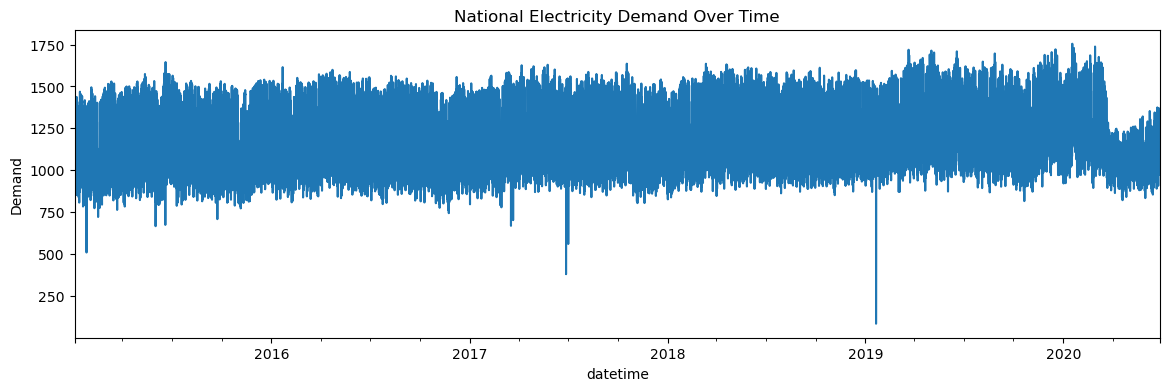

In [4]:
target_col = "nat_demand"

fig, ax = plt.subplots(figsize=(14, 4))
df[target_col].plot(ax=ax)
ax.set_title("National Electricity Demand Over Time")
ax.set_ylabel("Demand")
plt.show()

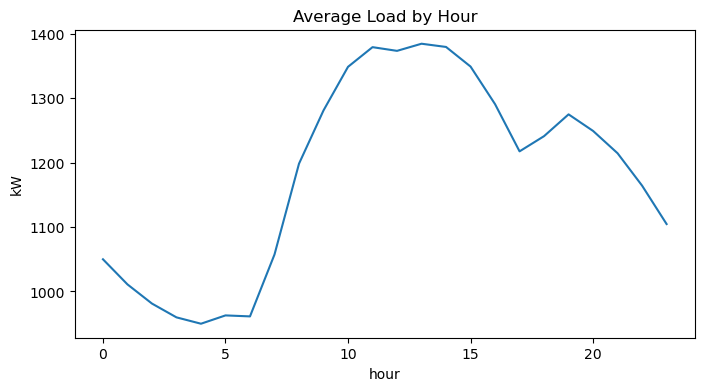

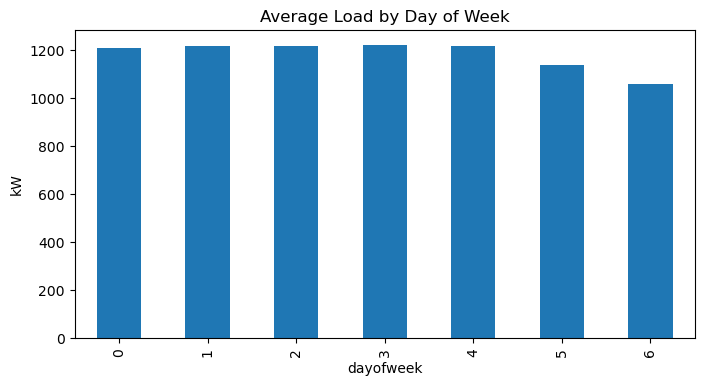

In [5]:
tmp = df.copy()
tmp["hour"] = tmp.index.hour
tmp["dayofweek"] = tmp.index.dayofweek

hourly_profile = tmp.groupby("hour")[target_col].mean()
daily_profile = tmp.groupby("dayofweek")[target_col].mean()

fig, ax = plt.subplots(figsize=(8, 4))
hourly_profile.plot(ax=ax)
ax.set_title("Average Load by Hour")
ax.set_ylabel("kW")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
daily_profile.plot(kind="bar", ax=ax)
ax.set_title("Average Load by Day of Week")
ax.set_ylabel("kW")
plt.show()

In [6]:
df_model = df.copy()

In [7]:
def add_time_features(data):
    data = data.copy()
    
    data["hour"] = data.index.hour
    data["dayofweek"] = data.index.dayofweek
    data["month"] = data.index.month
    data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)
    
    data["weekofyear"] = data.index.isocalendar().week.astype(int)
    data["is_month_start"] = data.index.is_month_start.astype(int)
    data["is_month_end"] = data.index.is_month_end.astype(int)
    
    data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
    data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)
    data["dow_sin"] = np.sin(2 * np.pi * data["dayofweek"] / 7)
    data["dow_cos"] = np.cos(2 * np.pi * data["dayofweek"] / 7)
    
    return data


def add_lag_features(data, target_col, lags):
    data = data.copy()
    for lag in lags:
        data[f"{target_col}_lag_{lag}"] = data[target_col].shift(lag)
    return data


def add_rolling_features(data, target_col, windows):
    data = data.copy()
    for w in windows:
        data[f"{target_col}_roll_mean_{w}"] = data[target_col].shift(1).rolling(w).mean()
        data[f"{target_col}_roll_std_{w}"] = data[target_col].shift(1).rolling(w).std()
        data[f"{target_col}_roll_min_{w}"] = data[target_col].shift(1).rolling(w).min()
        data[f"{target_col}_roll_max_{w}"] = data[target_col].shift(1).rolling(w).max()
    return data

In [8]:
target_col = "nat_demand"

base_lags = list(range(1, 25))
seasonal_lags = [48, 72, 168]
lags = sorted(set(base_lags + seasonal_lags))

rolling_windows = [3, 6, 12, 24, 168]

horizons = {
    "6h": 6,
    "12h": 12,
    "24h": 24
}

df_feat = df_model.copy()
df_feat = add_time_features(df_feat)
df_feat = add_lag_features(df_feat, target_col, lags)
df_feat = add_rolling_features(df_feat, target_col, rolling_windows)

df_feat.head()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,...,nat_demand_roll_min_12,nat_demand_roll_max_12,nat_demand_roll_mean_24,nat_demand_roll_std_24,nat_demand_roll_min_24,nat_demand_roll_max_24,nat_demand_roll_mean_168,nat_demand_roll_std_168,nat_demand_roll_min_168,nat_demand_roll_max_168
datetime,,,,,,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
horizons = {
    "6h": 6,
    "12h": 12,
    "24h": 24
}

for label, step in horizons.items():
    df_feat[f"target_{label}"] = df_feat[target_col].shift(-step)

df_feat.head()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,...,nat_demand_roll_std_24,nat_demand_roll_min_24,nat_demand_roll_max_24,nat_demand_roll_mean_168,nat_demand_roll_std_168,nat_demand_roll_min_168,nat_demand_roll_max_168,target_6h,target_12h,target_24h
datetime,,,,,,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,932.4876,1202.1556,944.0556
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1048.9720,1197.2616,928.7193
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1167.9074,1169.0034,909.5566
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1257.5069,1136.7054,894.6543
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1254.5830,1101.9447,884.6659


In [10]:
lag_features = [col for col in df_feat.columns if f"{target_col}_lag_" in col]

# lag + time + rolling + selected exogenous variables
time_features = [
    "hour", "dayofweek", "month", "is_weekend",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "weekofyear", "is_month_start", "is_month_end"
]

rolling_features = [col for col in df_feat.columns if "roll_" in col]

exo_features = [
    "T2M_toc", "QV2M_toc", "TQL_toc", "W2M_toc",
    "T2M_san", "QV2M_san", "TQL_san", "W2M_san",
    "T2M_dav", "QV2M_dav", "TQL_dav", "W2M_dav",
    "Holiday_ID", "holiday", "school"
]

feature_set_A = lag_features
feature_set_B = lag_features + time_features + rolling_features + exo_features

target_cols = [f"target_{k}" for k in horizons.keys()]

print("Feature set A:", len(feature_set_A))
print("Feature set B:", len(feature_set_B))
print("Targets:", target_cols)

Feature set A: 27
Feature set B: 73
Targets: ['target_6h', 'target_12h', 'target_24h']


In [11]:
model_data = df_feat.dropna().copy()

model_data["year"] = model_data.index.year
model_data["month"] = model_data.index.month

print(model_data.index.min(), "to", model_data.index.max())
print(model_data["year"].value_counts().sort_index())

2015-01-10 01:00:00 to 2020-06-26 00:00:00
year
2015    8543
2016    8784
2017    8760
2018    8760
2019    8760
2020    4249
Name: count, dtype: int64


In [12]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-6):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100


def evaluate_multihorizon(y_true, y_pred, target_names):
    rows = []
    for i, name in enumerate(target_names):
        yt = y_true[:, i]
        yp = y_pred[:, i]
        rows.append({
            "horizon": name,
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": rmse(yt, yp),
            "MAPE": mape(yt, yp)
        })
    return pd.DataFrame(rows)

In [13]:
cv_splits = [
    {
        "name": "train_2015_val_2016",
        "train_mask": model_data["year"] == 2015,
        "val_mask": model_data["year"] == 2016
    },
    {
        "name": "train_2015_2016_val_2017",
        "train_mask": model_data["year"].between(2015, 2016),
        "val_mask": model_data["year"] == 2017
    },
    {
        "name": "train_2015_2017_val_2018",
        "train_mask": model_data["year"].between(2015, 2017),
        "val_mask": model_data["year"] == 2018
    },
    {
        "name": "train_2015_2018_val_2019",
        "train_mask": model_data["year"].between(2015, 2018),
        "val_mask": model_data["year"] == 2019
    }
]

test_mask = (model_data["year"] == 2020) & (model_data["month"].isin([1, 2]))

print("Validation folds:")
for s in cv_splits:
    print(
        s["name"],
        "| train:", int(s["train_mask"].sum()),
        "| val:", int(s["val_mask"].sum())
    )

print("Final test size:", int(test_mask.sum()))

Validation folds:
train_2015_val_2016 | train: 8543 | val: 8784
train_2015_2016_val_2017 | train: 17327 | val: 8760
train_2015_2017_val_2018 | train: 26087 | val: 8760
train_2015_2018_val_2019 | train: 34847 | val: 8760
Final test size: 1440


In [14]:
def run_year_cv_model(data, feature_cols, target_cols, model, cv_splits):
    X = data[feature_cols].values
    y = data[target_cols].values
    
    fold_metrics = []
    all_preds = []
    
    for fold, split in enumerate(cv_splits, 1):
        train_idx = np.where(split["train_mask"].values)[0]
        val_idx = np.where(split["val_mask"].values)[0]
        
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        fold_result = evaluate_multihorizon(y_val, y_pred, target_cols)
        fold_result["fold"] = fold
        fold_result["split_name"] = split["name"]
        fold_metrics.append(fold_result)
        
        pred_df = pd.DataFrame(
            y_pred,
            columns=[f"pred_{c}" for c in target_cols],
            index=data.index[val_idx]
        )
        true_df = pd.DataFrame(
            y_val,
            columns=[f"true_{c}" for c in target_cols],
            index=data.index[val_idx]
        )
        merged = pd.concat([true_df, pred_df], axis=1)
        merged["fold"] = fold
        merged["split_name"] = split["name"]
        all_preds.append(merged)
    
    metrics_df = pd.concat(fold_metrics, ignore_index=True)
    preds_df = pd.concat(all_preds, axis=0)
    
    return metrics_df, preds_df

In [15]:
def run_final_test_model(data, feature_cols, target_cols, model, train_mask, test_mask):
    X = data[feature_cols].values
    y = data[target_cols].values
    
    train_idx = np.where(train_mask.values)[0]
    test_idx = np.where(test_mask.values)[0]
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    metrics_df = evaluate_multihorizon(y_test, y_pred, target_cols)
    
    pred_df = pd.DataFrame(
        y_pred,
        columns=[f"pred_{c}" for c in target_cols],
        index=data.index[test_idx]
    )
    true_df = pd.DataFrame(
        y_test,
        columns=[f"true_{c}" for c in target_cols],
        index=data.index[test_idx]
    )
    preds_df = pd.concat([true_df, pred_df], axis=1)
    
    return metrics_df, preds_df

In [16]:
final_train_mask = model_data["year"].between(2015, 2019)
final_test_mask = (model_data["year"] == 2020) & (model_data["month"].isin([1, 2]))

print("Final train size:", int(final_train_mask.sum()))
print("Final test size:", int(final_test_mask.sum()))

Final train size: 43607
Final test size: 1440


In [17]:
print("Final train period:",
      model_data.loc[final_train_mask].index.min(),
      "to",
      model_data.loc[final_train_mask].index.max())

print("Final test period:",
      model_data.loc[final_test_mask].index.min(),
      "to",
      model_data.loc[final_test_mask].index.max())

excluded_2020_mask = (model_data["year"] == 2020) & (~model_data["month"].isin([1, 2]))
print("Excluded 2020 period:",
      model_data.loc[excluded_2020_mask].index.min(),
      "to",
      model_data.loc[excluded_2020_mask].index.max())
print("Excluded observations:", int(excluded_2020_mask.sum()))

Final train period: 2015-01-10 01:00:00 to 2019-12-31 23:00:00
Final test period: 2020-01-01 00:00:00 to 2020-02-29 23:00:00
Excluded 2020 period: 2020-03-01 00:00:00 to 2020-06-26 00:00:00
Excluded observations: 2809


In [18]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lin_A_cv_metrics, lin_A_cv_preds = run_year_cv_model(
    data=model_data,
    feature_cols=feature_set_A,
    target_cols=target_cols,
    model=linear_model,
    cv_splits=cv_splits
)

order = ["target_6h", "target_12h", "target_24h"]

lin_A_cv_summary = (
    lin_A_cv_metrics
    .groupby("horizon")[["MAE", "RMSE", "MAPE"]]
    .mean()
    .reindex(order)
    .round(4)
)
lin_A_cv_summary

,MAE,RMSE,MAPE
horizon,,,
target_6h,67.5241,98.3943,5.6015
target_12h,79.2925,109.8046,6.4956
target_24h,79.6268,107.9172,6.5821


In [19]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_results = []

for alpha in alphas:
    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])
    
    metrics_df, _ = run_year_cv_model(
        data=model_data,
        feature_cols=feature_set_A,
        target_cols=target_cols,
        model=ridge_model,
        cv_splits=cv_splits
    )
    
    avg_rmse = metrics_df["RMSE"].mean()
    ridge_results.append({"alpha": alpha, "avg_RMSE": avg_rmse})

ridge_tuning = pd.DataFrame(ridge_results).sort_values("avg_RMSE")
ridge_tuning

,alpha,avg_RMSE
2,1.00,105.372000
1,0.10,105.372043
0,0.01,105.372054
3,10.00,105.376976
4,100.00,105.552558


In [20]:
best_alpha = ridge_tuning.iloc[0]["alpha"]
print("Best alpha:", best_alpha)

Best alpha: 1.0


In [21]:
ridge_A_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=best_alpha))
])

ridge_A_cv_metrics, ridge_A_cv_preds = run_year_cv_model(
    data=model_data,
    feature_cols=feature_set_A,
    target_cols=target_cols,
    model=ridge_A_model,
    cv_splits=cv_splits
)

ridge_A_cv_summary = (
    ridge_A_cv_metrics
    .groupby("horizon")[["MAE", "RMSE", "MAPE"]]
    .mean()
    .reindex(order)
    .round(4)
)
ridge_A_cv_summary

,MAE,RMSE,MAPE
horizon,,,
target_6h,67.5206,98.3950,5.6011
target_12h,79.2924,109.8042,6.4956
target_24h,79.6302,107.9168,6.5824


In [22]:
ridge_B_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=best_alpha))
])

ridge_B_cv_metrics, ridge_B_cv_preds = run_year_cv_model(
    data=model_data,
    feature_cols=feature_set_B,
    target_cols=target_cols,
    model=ridge_B_model,
    cv_splits=cv_splits
)

ridge_B_cv_summary = (
    ridge_B_cv_metrics
    .groupby("horizon")[["MAE", "RMSE", "MAPE"]]
    .mean()
    .reindex(order)
    .round(4)
)
ridge_B_cv_summary

,MAE,RMSE,MAPE
horizon,,,
target_6h,48.7564,65.9995,4.2503
target_12h,59.9892,81.8050,5.1174
target_24h,63.0282,81.9586,5.4191


In [23]:
lin_A_test_metrics, lin_A_test_preds = run_final_test_model(
    data=model_data,
    feature_cols=feature_set_A,
    target_cols=target_cols,
    model=linear_model,
    train_mask=final_train_mask,
    test_mask=final_test_mask
)

lin_A_test_metrics

,horizon,MAE,RMSE,MAPE
0,target_6h,77.145723,106.590307,5.933949
1,target_12h,93.131519,122.935565,7.053117
2,target_24h,90.249516,118.077244,6.916126


In [24]:
ridge_A_test_metrics, ridge_A_test_preds = run_final_test_model(
    data=model_data,
    feature_cols=feature_set_A,
    target_cols=target_cols,
    model=ridge_A_model,
    train_mask=final_train_mask,
    test_mask=final_test_mask
)

ridge_A_test_metrics

,horizon,MAE,RMSE,MAPE
0,target_6h,77.147517,106.592868,5.934053
1,target_12h,93.132173,122.935605,7.053162
2,target_24h,90.250834,118.077853,6.916249


In [25]:
ridge_B_test_metrics, ridge_B_test_preds = run_final_test_model(
    data=model_data,
    feature_cols=feature_set_B,
    target_cols=target_cols,
    model=ridge_B_model,
    train_mask=final_train_mask,
    test_mask=final_test_mask
)

ridge_B_test_metrics

,horizon,MAE,RMSE,MAPE
0,target_6h,55.383905,73.891042,4.472527
1,target_12h,68.653103,93.256780,5.431539
2,target_24h,72.349928,94.607236,5.755570


In [26]:
def add_model_name(summary_df, model_name):
    out = summary_df.copy().reset_index()
    out["model"] = model_name
    return out

comparison_cv = pd.concat([
    add_model_name(lin_A_cv_summary, "Linear_A_lag_only"),
    add_model_name(ridge_A_cv_summary, "Ridge_A_lag_only"),
    add_model_name(ridge_B_cv_summary, "Ridge_B_full_features")
], ignore_index=True)

comparison_cv["horizon_order"] = comparison_cv["horizon"].map({
    "target_6h": 1,
    "target_12h": 2,
    "target_24h": 3
})

comparison_cv = comparison_cv.sort_values(["model", "horizon_order"])
comparison_cv

,horizon,MAE,RMSE,MAPE,model,horizon_order
0,target_6h,67.5241,98.3943,5.6015,Linear_A_lag_only,1
1,target_12h,79.2925,109.8046,6.4956,Linear_A_lag_only,2
2,target_24h,79.6268,107.9172,6.5821,Linear_A_lag_only,3
3,target_6h,67.5206,98.3950,5.6011,Ridge_A_lag_only,1
4,target_12h,79.2924,109.8042,6.4956,Ridge_A_lag_only,2
5,target_24h,79.6302,107.9168,6.5824,Ridge_A_lag_only,3
6,target_6h,48.7564,65.9995,4.2503,Ridge_B_full_features,1
7,target_12h,59.9892,81.8050,5.1174,Ridge_B_full_features,2
8,target_24h,63.0282,81.9586,5.4191,Ridge_B_full_features,3


In [27]:
comparison_test = pd.concat([
    add_model_name(lin_A_test_metrics.set_index("horizon"), "Linear_A_lag_only"),
    add_model_name(ridge_A_test_metrics.set_index("horizon"), "Ridge_A_lag_only"),
    add_model_name(ridge_B_test_metrics.set_index("horizon"), "Ridge_B_full_features")
], ignore_index=True)

comparison_test["horizon_order"] = comparison_test["horizon"].map({
    "target_6h": 1,
    "target_12h": 2,
    "target_24h": 3
})

comparison_test = comparison_test.sort_values(["model", "horizon_order"])
comparison_test

,horizon,MAE,RMSE,MAPE,model,horizon_order
0,target_6h,77.145723,106.590307,5.933949,Linear_A_lag_only,1
1,target_12h,93.131519,122.935565,7.053117,Linear_A_lag_only,2
2,target_24h,90.249516,118.077244,6.916126,Linear_A_lag_only,3
3,target_6h,77.147517,106.592868,5.934053,Ridge_A_lag_only,1
4,target_12h,93.132173,122.935605,7.053162,Ridge_A_lag_only,2
5,target_24h,90.250834,118.077853,6.916249,Ridge_A_lag_only,3
6,target_6h,55.383905,73.891042,4.472527,Ridge_B_full_features,1
7,target_12h,68.653103,93.256780,5.431539,Ridge_B_full_features,2
8,target_24h,72.349928,94.607236,5.755570,Ridge_B_full_features,3


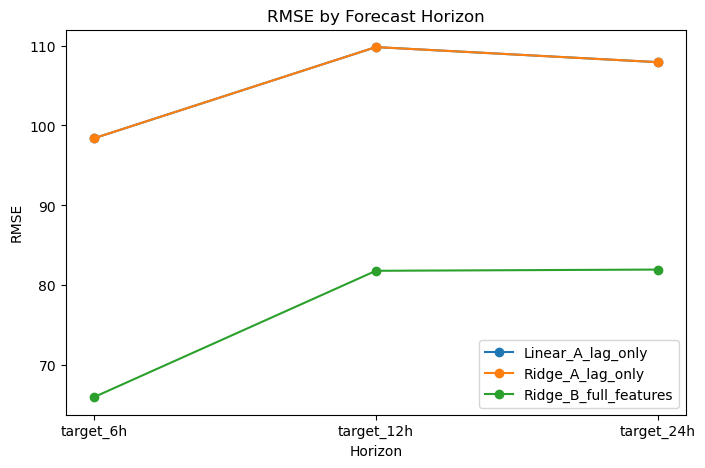

In [28]:
plot_df = comparison_cv.copy()
plot_df["horizon_order"] = plot_df["horizon"].map({
    "target_6h": 1,
    "target_12h": 2,
    "target_24h": 3
})
plot_df = plot_df.sort_values(["model", "horizon_order"])

fig, ax = plt.subplots(figsize=(8, 5))
for model_name, grp in plot_df.groupby("model"):
    ax.plot(grp["horizon"], grp["RMSE"], marker="o", label=model_name)

ax.set_title("RMSE by Forecast Horizon")
ax.set_xlabel("Horizon")
ax.set_ylabel("RMSE")
ax.legend()
plt.show()

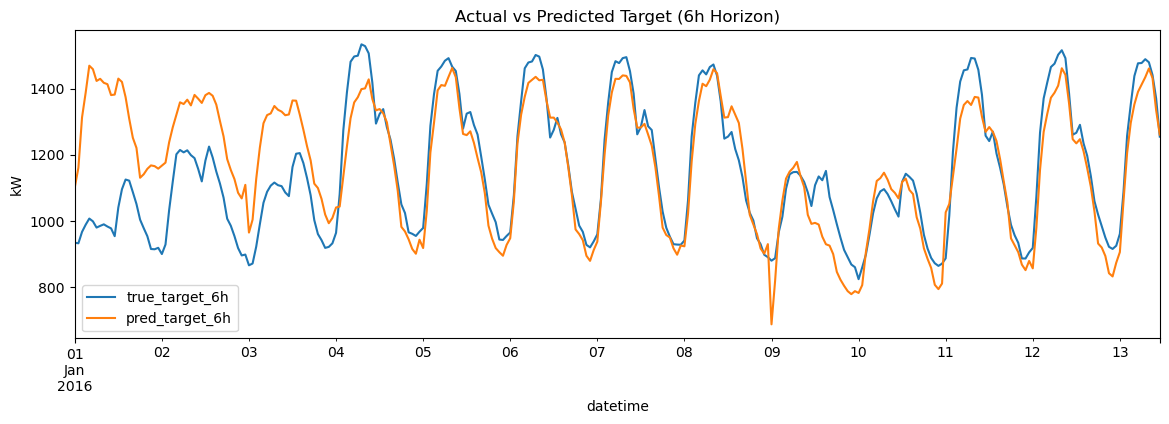

In [29]:
example = ridge_B_cv_preds.copy()

col_true = "true_target_6h"
col_pred = "pred_target_6h"

fig, ax = plt.subplots(figsize=(14, 4))
example[[col_true, col_pred]].iloc[:300].plot(ax=ax)
ax.set_title("Actual vs Predicted Target (6h Horizon)")
ax.set_ylabel("kW")
plt.show()

In [30]:
model_data.loc[model_data["year"] == 2020].index.min(), model_data.loc[model_data["year"] == 2020].index.max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2020-06-26 00:00:00'))

In [31]:
# Fit on full dataset for interpretation only
X_full = model_data[feature_set_B].values
y_full = model_data[target_cols].values

ridge_final = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=best_alpha))
])

ridge_final.fit(X_full, y_full)

coefs = ridge_final.named_steps["model"].coef_

coef_df = pd.DataFrame(
    coefs.T,
    index=feature_set_B,
    columns=target_cols
)

coef_df.head()

,target_6h,target_12h,target_24h
nat_demand_lag_1,36.448683,39.160330,130.522191
nat_demand_lag_2,-58.312865,10.014253,-54.090071
nat_demand_lag_3,-53.332142,-12.425101,-22.070600
nat_demand_lag_4,-15.289734,-13.126286,-17.958309
nat_demand_lag_5,23.104737,4.832154,20.736045


In [32]:
# Top absolute coefficients for 6h horizon
top_features_6h = coef_df["target_6h"].abs().sort_values(ascending=False).head(20)
top_features_6h

nat_demand_roll_min_3      331.954517
nat_demand_roll_max_3      230.700473
nat_demand_lag_18          108.673558
nat_demand_roll_std_3      102.144754
dayofweek                   78.851597
nat_demand_lag_2            58.312865
nat_demand_lag_3            53.332142
nat_demand_roll_std_24      46.505652
hour_cos                    45.486115
dow_cos                     43.604761
nat_demand_lag_1            36.448683
nat_demand_roll_max_6       34.427677
nat_demand_roll_max_168     34.209529
nat_demand_lag_168          33.915929
nat_demand_roll_min_6       33.094237
nat_demand_roll_min_24      33.088223
nat_demand_lag_17           31.783841
holiday                     31.591564
hour_sin                    29.425955
nat_demand_lag_23           28.525851
Name: target_6h, dtype: float64

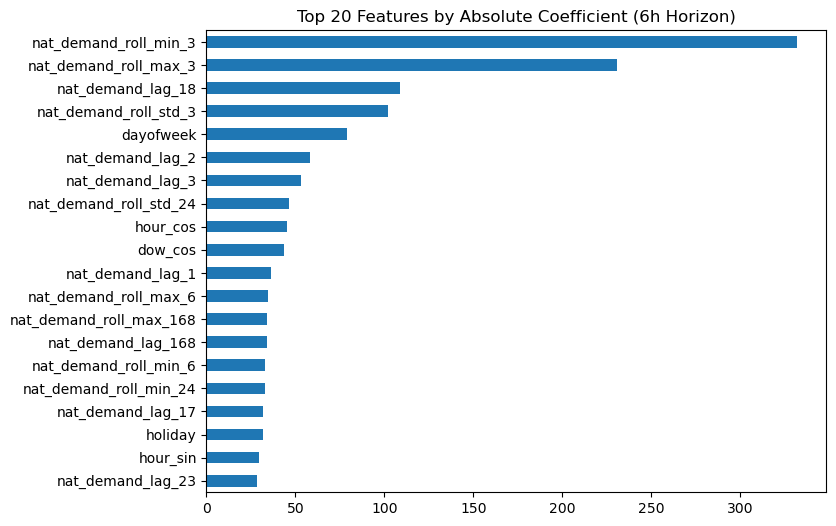

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))
top_features_6h.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 Features by Absolute Coefficient (6h Horizon)")
plt.show()

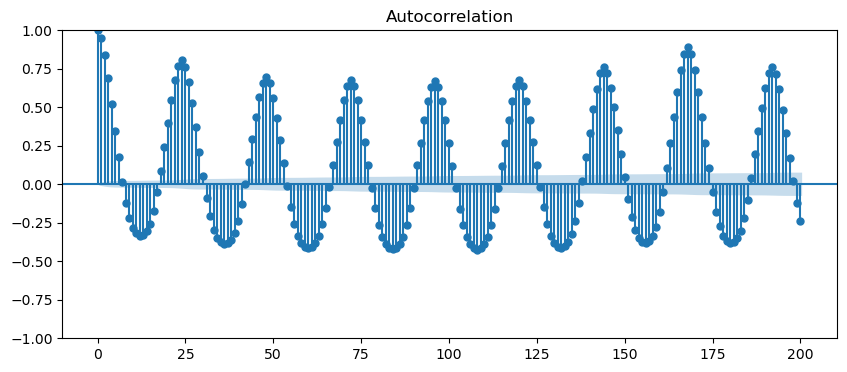

In [34]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10,4))
plot_acf(df[target_col], lags=200, ax=ax)
plt.show()

In [35]:
comparison_cv["horizon"] = pd.Categorical(
    comparison_cv["horizon"],
    categories=["target_6h", "target_12h", "target_24h"],
    ordered=True
)

comparison_cv = comparison_cv.sort_values(["model", "horizon"])

comparison_pivot = comparison_cv.pivot(index="horizon", columns="model", values="RMSE")
comparison_pivot.index = comparison_pivot.index.str.replace("target_", "")
comparison_pivot

model,Linear_A_lag_only,Ridge_A_lag_only,Ridge_B_full_features
horizon,,,
6h,98.3943,98.3950,65.9995
12h,109.8046,109.8042,81.8050
24h,107.9172,107.9168,81.9586


In [36]:
#Forecast error increases significantly from 6 to 12 hours ahead, but shows limited additional degradation between 12 and 24 hours, suggesting that demand becomes less dependent on recent observations and more driven by stable seasonal patterns.
#Expanding-window validation was conducted using yearly splits from 2015–2019. Final out-of-sample testing used January–February 2020 only. Observations from March–June 2020 were excluded from the main evaluation to preserve a fixed hold-out period and avoid contamination from potentially atypical demand conditions.

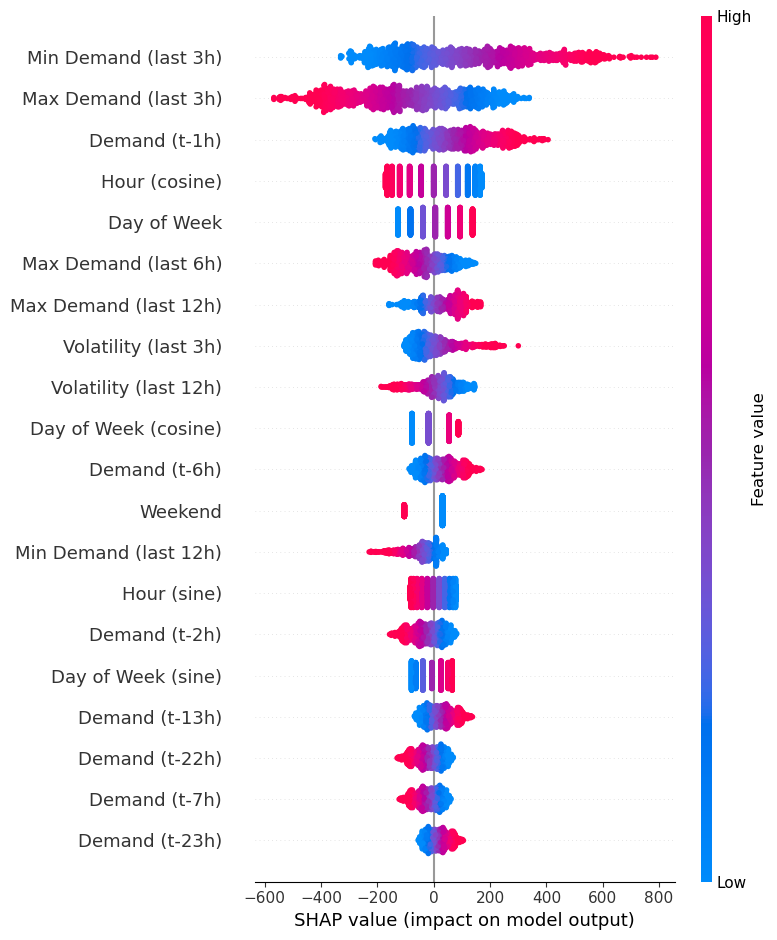

In [38]:
import shap

feature_name_map = {
    "nat_demand_lag_1": "Demand (t-1h)",
    "nat_demand_lag_2": "Demand (t-2h)",
    "nat_demand_lag_6": "Demand (t-6h)",
    "nat_demand_lag_7": "Demand (t-7h)",
    "nat_demand_lag_13": "Demand (t-13h)",
    "nat_demand_lag_22": "Demand (t-22h)",
    "nat_demand_lag_23": "Demand (t-23h)",

    "nat_demand_roll_min_3": "Min Demand (last 3h)",
    "nat_demand_roll_max_3": "Max Demand (last 3h)",
    "nat_demand_roll_max_6": "Max Demand (last 6h)",
    "nat_demand_roll_max_12": "Max Demand (last 12h)",
    "nat_demand_roll_min_12": "Min Demand (last 12h)",
    "nat_demand_roll_std_3": "Volatility (last 3h)",
    "nat_demand_roll_std_12": "Volatility (last 12h)",

    "hour_cos": "Hour (cosine)",
    "hour_sin": "Hour (sine)",
    "dayofweek": "Day of Week",
    "dow_cos": "Day of Week (cosine)",
    "dow_sin": "Day of Week (sine)",
    "is_weekend": "Weekend"
}

X_train_final = model_data.loc[final_train_mask, feature_set_B]
X_test_final  = model_data.loc[final_test_mask, feature_set_B]

target_name = "target_24h"
y_train_single = model_data.loc[final_train_mask, target_name]

ridge_single = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=best_alpha))
])

ridge_single.fit(X_train_final, y_train_single)

scaler = ridge_single.named_steps["scaler"]
model = ridge_single.named_steps["model"]

X_train_scaled = scaler.transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer(X_test_scaled)

feature_names_readable = [
    feature_name_map.get(f, f) for f in feature_set_B
]

shap.summary_plot(
    shap_values.values,
    X_test_final,
    feature_names=feature_names_readable
)

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import pandas as pd
import numpy as np

def add_model_name(df, name):
    out = df.copy().reset_index()
    out["model"] = name
    return out

def summarize_metrics(metrics_df):
    return (metrics_df
            .groupby("horizon")[["MAE","RMSE","MAPE"]]
            .mean()
            .reindex(["target_6h","target_12h","target_24h"])
            .round(4))

baseline_alpha = 1.0

ridge_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=baseline_alpha))
])

base_cv_metrics, _ = run_year_cv_model(
    data=model_data,
    feature_cols=feature_set_B,
    target_cols=target_cols,
    model=ridge_base,
    cv_splits=cv_splits
)
base_cv_summary = summarize_metrics(base_cv_metrics)

base_test_metrics, _ = run_final_test_model(
    data=model_data,
    feature_cols=feature_set_B,
    target_cols=target_cols,
    model=ridge_base,
    train_mask=final_train_mask,
    test_mask=final_test_mask
)
base_test_summary = base_test_metrics.set_index("horizon").reindex(
    ["target_6h","target_12h","target_24h"]
)[["MAE","RMSE","MAPE"]].round(4)

print("Baseline (alpha=1.0) — CV:")
display(base_cv_summary)
print("Baseline (alpha=1.0) — Test:")
display(base_test_summary)


alphas = [0.01, 0.1, 1, 5, 10, 20, 50, 100]

tuning_rows = []
for a in alphas:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=a))
    ])
    cv_metrics, _ = run_year_cv_model(
        data=model_data,
        feature_cols=feature_set_B,
        target_cols=target_cols,
        model=model,
        cv_splits=cv_splits
    )
    # average RMSE across horizons & folds
    avg_rmse = cv_metrics["RMSE"].mean()
    avg_mape = cv_metrics["MAPE"].mean()
    tuning_rows.append({"alpha": a, "avg_RMSE": avg_rmse, "avg_MAPE": avg_mape})

tuning_df = pd.DataFrame(tuning_rows).sort_values("avg_RMSE")
print("\nTuning results (sorted by avg RMSE):")
display(tuning_df)

best_alpha = tuning_df.iloc[0]["alpha"]
print(f"\nBest alpha (by CV RMSE): {best_alpha}")


ridge_tuned = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=best_alpha))
])

tuned_cv_metrics, _ = run_year_cv_model(
    data=model_data,
    feature_cols=feature_set_B,
    target_cols=target_cols,
    model=ridge_tuned,
    cv_splits=cv_splits
)
tuned_cv_summary = summarize_metrics(tuned_cv_metrics)

tuned_test_metrics, _ = run_final_test_model(
    data=model_data,
    feature_cols=feature_set_B,
    target_cols=target_cols,
    model=ridge_tuned,
    train_mask=final_train_mask,
    test_mask=final_test_mask
)
tuned_test_summary = tuned_test_metrics.set_index("horizon").reindex(
    ["target_6h","target_12h","target_24h"]
)[["MAE","RMSE","MAPE"]].round(4)

print("\nTuned — CV:")
display(tuned_cv_summary)
print("Tuned — Test:")
display(tuned_test_summary)

def compare_tables(before_df, after_df, label):
    comp = before_df.copy()
    comp.columns = [f"{c}_before" for c in comp.columns]
    for c in ["MAE","RMSE","MAPE"]:
        comp[f"{c}_after"] = after_df[c]
        comp[f"{c}_delta"] = comp[f"{c}_after"] - comp[f"{c}_before"]
    comp.index = comp.index.str.replace("target_","")
    print(f"\nComparison — {label}")
    return comp.round(4)

cv_comparison = compare_tables(base_cv_summary, tuned_cv_summary, "CV (validation)")
test_comparison = compare_tables(base_test_summary, tuned_test_summary, "Final Test")

display(cv_comparison)
display(test_comparison)

def pct_improve(before, after):
    return (before - after) / before * 100

improve_rows = []
for h in ["target_6h","target_12h","target_24h"]:
    improve_rows.append({
        "horizon": h.replace("target_",""),
        "RMSE_improve_% (CV)": pct_improve(base_cv_summary.loc[h,"RMSE"], tuned_cv_summary.loc[h,"RMSE"]),
        "MAPE_improve_% (CV)": pct_improve(base_cv_summary.loc[h,"MAPE"], tuned_cv_summary.loc[h,"MAPE"]),
        "RMSE_improve_% (Test)": pct_improve(base_test_summary.loc[h,"RMSE"], tuned_test_summary.loc[h,"RMSE"]),
        "MAPE_improve_% (Test)": pct_improve(base_test_summary.loc[h,"MAPE"], tuned_test_summary.loc[h,"MAPE"]),
    })

improve_df = pd.DataFrame(improve_rows).round(2)
print("\nPercentage improvement (+ means better after tuning):")
display(improve_df)

Baseline (alpha=1.0) — CV:


,MAE,RMSE,MAPE
horizon,,,
target_6h,48.7564,65.9995,4.2503
target_12h,59.9892,81.8050,5.1174
target_24h,63.0282,81.9586,5.4191


Baseline (alpha=1.0) — Test:


,MAE,RMSE,MAPE
horizon,,,
target_6h,55.3839,73.8910,4.4725
target_12h,68.6531,93.2568,5.4315
target_24h,72.3499,94.6072,5.7556



Tuning results (sorted by avg RMSE):


...


Comparison — CV (validation)

Comparison — Final Test


,MAE_before,RMSE_before,MAPE_before,MAE_after,MAE_delta,RMSE_after,RMSE_delta,MAPE_after,MAPE_delta
horizon,,,,,,,,,
6h,48.7564,65.9995,4.2503,48.6706,-0.0858,65.5433,-0.4562,4.2348,-0.0155
12h,59.9892,81.8050,5.1174,59.4807,-0.5085,81.3629,-0.4421,5.0686,-0.0488
24h,63.0282,81.9586,5.4191,63.2581,0.2299,81.9741,0.0155,5.4291,0.0100


,MAE_before,RMSE_before,MAPE_before,MAE_after,MAE_delta,RMSE_after,RMSE_delta,MAPE_after,MAPE_delta
horizon,,,,,,,,,
6h,55.3839,73.8910,4.4725,55.3540,-0.0299,73.8566,-0.0344,4.4678,-0.0047
12h,68.6531,93.2568,5.4315,68.6705,0.0174,93.3736,0.1168,5.4324,0.0009
24h,72.3499,94.6072,5.7556,72.5247,0.1748,94.8855,0.2783,5.7668,0.0112



Percentage improvement (+ means better after tuning):


,horizon,RMSE_improve_% (CV),MAPE_improve_% (CV),RMSE_improve_% (Test),MAPE_improve_% (Test)
0,6h,0.69,0.36,0.05,0.11
1,12h,0.54,0.95,-0.13,-0.02
2,24h,-0.02,-0.18,-0.29,-0.19
